In [1]:
import pandas as pd

df = pd.read_csv("results.csv")
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [2]:
df.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral'],
      dtype='object')

In [5]:
df_wc = df[df["tournament"] == "FIFA World Cup"].copy()
df_wc.shape

(1036, 9)

In [6]:
def get_result(row):
    if row["home_score"] > row["away_score"]:
        return "home_win"
    elif row["home_score"] < row["away_score"]:
        return "away_win"
    else:
        return "draw"

df_wc["result"] = df_wc.apply(get_result, axis=1)

In [7]:
rankings = pd.read_csv("fifa_ranking-2024-06-20.csv")

df_wc["date"] = pd.to_datetime(df_wc["date"])
rankings["rank_date"] = pd.to_datetime(rankings["rank_date"])

# FIFA ranking data starts from 1992
df_wc = df_wc[df_wc["date"] >= "1992-12-31"].copy()

rankings = rankings.rename(columns={
    "country_full": "team",
    "rank_date": "date"
})

rankings = rankings[["date", "team", "rank", "total_points"]].copy()

team_fix = {
    "South Korea": "Korea Republic",
    "North Korea": "Korea DPR",
    "United States": "USA",
    "Iran": "IR Iran",
    "Ivory Coast": "Côte d'Ivoire",
    "DR Congo": "Congo DR",
    "Czech Republic": "Czechia",
    "Cape Verde": "Cabo Verde",
    "Curaçao": "Curacao"
}

df_wc["home_team_rank_name"] = df_wc["home_team"].replace(team_fix)
df_wc["away_team_rank_name"] = df_wc["away_team"].replace(team_fix)

def merge_team_ranking(matches, rankings, team_col, prefix):
    left = matches.sort_values(["date", team_col]).copy()
    right = rankings.sort_values(["date", "team"]).copy()
    
    merged = pd.merge_asof(
        left,
        right,
        on="date",
        left_by=team_col,
        right_by="team",
        direction="backward"
    )
    
    merged = merged.rename(columns={
        "rank": f"{prefix}_rank",
        "total_points": f"{prefix}_points"
    })
    
    merged = merged.drop(columns=["team"])
    return merged

df_wc = merge_team_ranking(df_wc, rankings, "home_team_rank_name", "home")
df_wc = merge_team_ranking(df_wc, rankings, "away_team_rank_name", "away")

print(df_wc[["home_rank", "away_rank"]].isna().sum())

df_wc = df_wc.dropna(subset=["home_rank", "away_rank"]).copy()

df_wc["rank_diff"] = df_wc["home_rank"] - df_wc["away_rank"]

def is_upset(row):
    if row["home_rank"] > row["away_rank"] and row["result"] == "home_win":
        return 1
    elif row["away_rank"] > row["home_rank"] and row["result"] == "away_win":
        return 1
    else:
        return 0

df_wc["upset"] = df_wc.apply(is_upset, axis=1)

df_wc[["date", "home_team", "away_team", "home_rank", "away_rank", "rank_diff", "result", "upset"]].head()

home_rank    1
away_rank    3
dtype: int64


,date,home_team,away_team,home_rank,away_rank,rank_diff,result,upset
0,1994-06-17,Germany,Bolivia,1.0,43.0,-42.0,home_win,0
1,1994-06-17,Spain,South Korea,5.0,37.0,-32.0,draw,0
2,1994-06-18,Italy,Republic of Ireland,4.0,14.0,-10.0,away_win,1
3,1994-06-18,Colombia,Romania,17.0,7.0,10.0,away_win,0
4,1994-06-18,United States,Switzerland,23.0,12.0,11.0,draw,0


In [8]:
df_wc = df_wc.dropna(subset=["home_rank", "away_rank"]).copy()

print(df_wc.shape)
print(df_wc["result"].value_counts())
print(df_wc["upset"].value_counts())

df_wc[["date", "home_team", "away_team", "home_score", "away_score",
       "home_rank", "away_rank", "rank_diff", "result", "upset"]].head(10)

(568, 18)
result
home_win    219
draw        189
away_win    160
Name: count, dtype: int64
upset
0    457
1    111
Name: count, dtype: int64


,date,home_team,away_team,home_score,away_score,home_rank,away_rank,rank_diff,result,upset
0,1994-06-17,Germany,Bolivia,1.0,0.0,1.0,43.0,-42.0,home_win,0
1,1994-06-17,Spain,South Korea,2.0,2.0,5.0,37.0,-32.0,draw,0
2,1994-06-18,Italy,Republic of Ireland,0.0,1.0,4.0,14.0,-10.0,away_win,1
3,1994-06-18,Colombia,Romania,1.0,3.0,17.0,7.0,10.0,away_win,0
4,1994-06-18,United States,Switzerland,1.0,1.0,23.0,12.0,11.0,draw,0
5,1994-06-19,Norway,Mexico,1.0,0.0,6.0,16.0,-10.0,home_win,0
6,1994-06-19,Belgium,Morocco,1.0,0.0,27.0,28.0,-1.0,home_win,0
7,1994-06-19,Cameroon,Sweden,2.0,2.0,24.0,10.0,14.0,draw,0
8,1994-06-20,Brazil,Russia,2.0,0.0,3.0,19.0,-16.0,home_win,0
9,1994-06-20,Netherlands,Saudi Arabia,2.0,1.0,2.0,34.0,-32.0,home_win,0


In [9]:
# Extra features
df_wc["rank_gap"] = abs(df_wc["rank_diff"])
df_wc["is_neutral"] = df_wc["neutral"].astype(int)

# Goal difference
df_wc["goal_diff"] = df_wc["home_score"] - df_wc["away_score"]

# Quick summary
print(df_wc[["rank_diff", "rank_gap", "is_neutral", "goal_diff", "upset"]].describe())

        rank_diff    rank_gap  is_neutral   goal_diff       upset
count  568.000000  568.000000  568.000000  496.000000  568.000000
mean    -2.815141   20.762324    0.901408    0.290323    0.195423
std     26.802682   17.160664    0.298376    1.802464    0.396875
min   -104.000000    1.000000    0.000000   -6.000000    0.000000
25%    -19.000000    7.750000    1.000000   -1.000000    0.000000
50%     -4.000000   16.500000    1.000000    0.000000    0.000000
75%     13.000000   29.000000    1.000000    1.000000    0.000000
max    104.000000  104.000000    1.000000    8.000000    1.000000


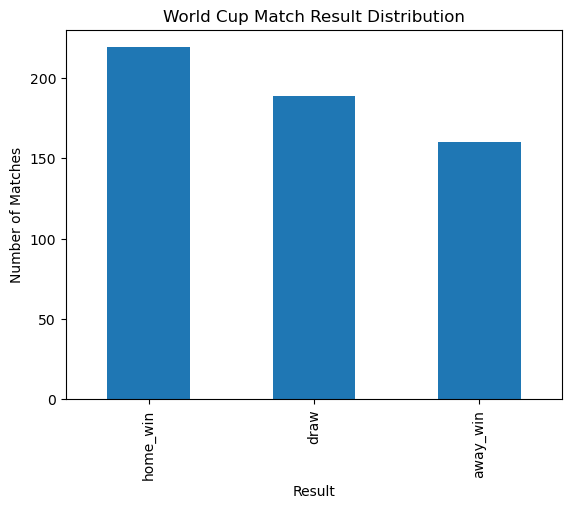

In [10]:
import matplotlib.pyplot as plt

df_wc["result"].value_counts().plot(kind="bar")
plt.title("World Cup Match Result Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Matches")
plt.show()

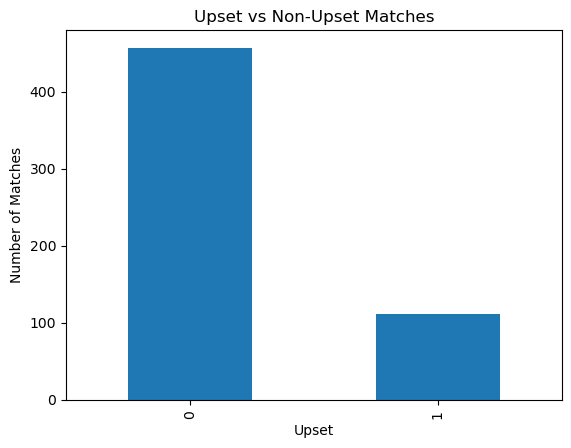

In [11]:
df_wc["upset"].value_counts().plot(kind="bar")
plt.title("Upset vs Non-Upset Matches")
plt.xlabel("Upset")
plt.ylabel("Number of Matches")
plt.show()

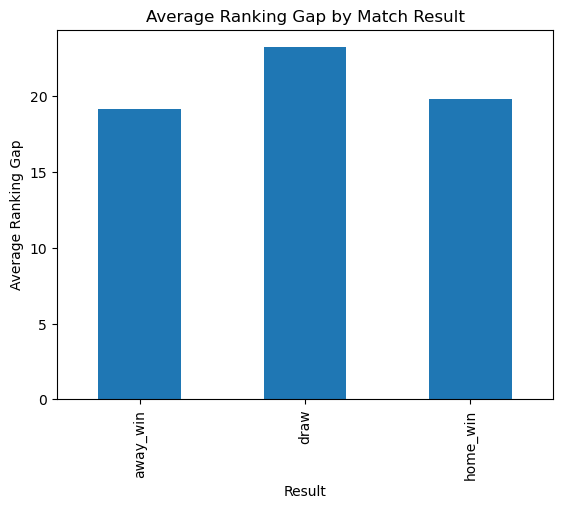

In [12]:
df_wc.groupby("result")["rank_gap"].mean().plot(kind="bar")
plt.title("Average Ranking Gap by Match Result")
plt.xlabel("Result")
plt.ylabel("Average Ranking Gap")
plt.show()